# 24회차 기출


## 문제 1

**Data description**

-   **sex** : 성별

-   **age** : 나이

-   **pstatus** : 부모와의 동거 유무(T : 동거 o, A : 동거 x)

-   **medu** : 엄마의 교육수준

    -   0 : none

    -   1 : 초등교육(초등학교)

    -   2 : 5 \~ 9th edu

    -   3 : 중등교육(중학교, 고등학교)

    -   4 : 고등교육(대학, 대학원수준)

-   **fedu** : 아빠의 교육수준

    -   0 : none

    -   1 : 초등교육(초등학교)

    -   2 : 5 \~ 9th edu(5\~9학년)

    -   3 : 중등교육(중학교, 고등학교)

    -   4 : 고등교육(대학, 대학원수준)

-   **guardian** : 주보호자

    -   어머니

    -   아버지

    -   기타

-   **traveltime** : 등하교기간

    -   1 : 15분 이하

    -   2 : 15분 \~ 30분 이하

    -   3 : 30분 \~ 1시간 이하

    -   4 : 1시간 이상

-   **studytime** : 학습시간

    -   1 : 2시간 이하

    -   2 : 2\~5시간 이하

    -   3 : 5\~10시간 이하

    -   4 : 10시간 이상

-   **failure** : 학사경고 횟수

-   **freetime** : 자유시간(1 : 매우 낮음 \~ 5 : 매우 높음)

-   **famrel** : 가족관계(1 : 매우나쁨 \~ 5 : 매우우수)

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import warnings
warnings.filterwarnings('ignore')

In [81]:
d1 = pd.read_csv('problem1.csv')

In [82]:
print(d1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sex         395 non-null    object 
 1   age         395 non-null    int64  
 2   pstatus     395 non-null    object 
 3   medu        391 non-null    float64
 4   fedu        395 non-null    int64  
 5   guardian    395 non-null    object 
 6   traveltime  395 non-null    int64  
 7   studytime   395 non-null    int64  
 8   failures    395 non-null    int64  
 9   freetime    395 non-null    int64  
 10  famrel      395 non-null    int64  
 11  absences    389 non-null    float64
dtypes: float64(2), int64(7), object(3)
memory usage: 37.2+ KB
None


In [83]:
d1.head(3)

,sex,age,pstatus,medu,fedu,guardian,traveltime,studytime,failures,freetime,famrel,absences
0,F,18,A,NaN,4,mother,2,2,0,3,4,6.0
1,F,17,T,NaN,1,father,1,2,0,3,5,4.0
2,F,15,T,NaN,1,mother,1,2,3,3,4,10.0


1.  **탐색적 데이터 분석을 실시하시오. 논리적이고 타당한 근거를 들어 작성하시오(시각화 포함)(5점).**

순위형 명목변수를 카테고리형 변환 필요(추후 라벨인코더 사용)

In [84]:
d1.isna().sum()

sex           0
age           0
pstatus       0
medu          4
fedu          0
guardian      0
traveltime    0
studytime     0
failures      0
freetime      0
famrel        0
absences      6
dtype: int64

medu, absences에 4, 6개의 결측치가 존재함. 

In [85]:
num_cols

['age', 'failures', 'absences']

<<연속/이산형 변수 통계량 및 시각화>>


,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
absences,389.0,5.745501,8.045586,0.0,0.0,4.0,8.0,75.0


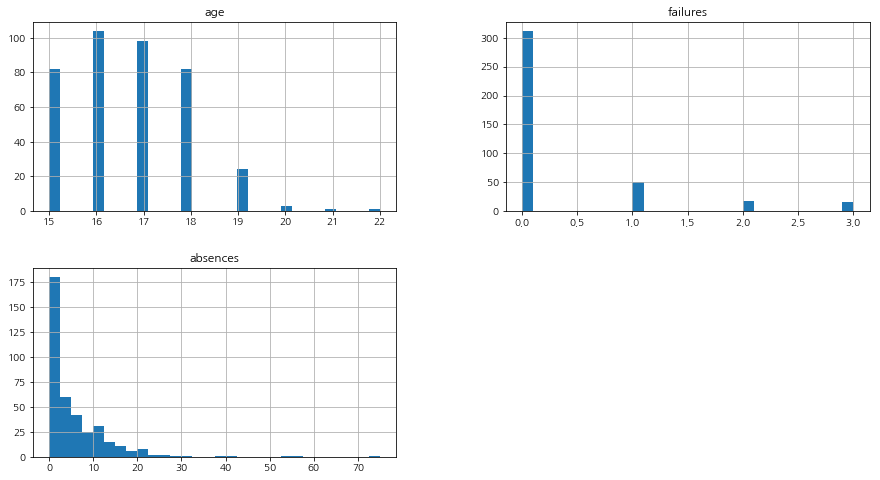

<<명목형 변수 통계량 및 시각화>>


,count,mean,std,min,25%,50%,75%,max
medu,391.0,2.751918,1.089502,0.0,2.0,3.0,4.0,4.0
fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0


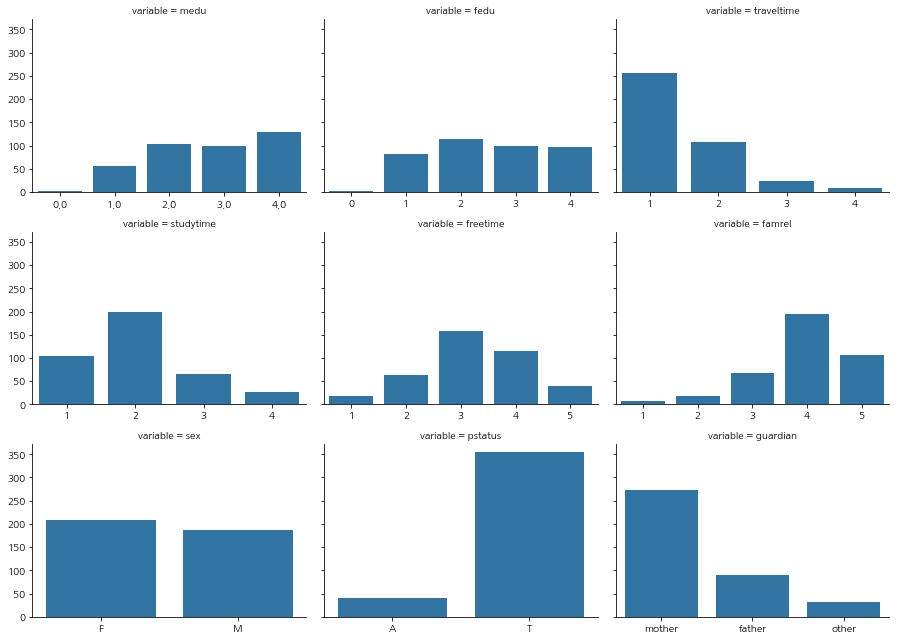

In [86]:
cat_cols = ['medu', 'fedu', 'traveltime', 'studytime', 'freetime', 'famrel', 'sex', 'pstatus', 'guardian']

num_cols = ['age', 'failures', 'absences']

print("<<연속/이산형 변수 통계량 및 시각화>>")
display(d1[num_cols].describe().T)
d1[num_cols].hist(figsize=(15, 8), bins=30)
plt.show()

print("<<명목형 변수 통계량 및 시각화>>")
display(d1[cat_cols].describe().T)
mt = d1[cat_cols].melt()
g = sns.FacetGrid(
    mt, col='variable', 
    col_wrap=3, 
    height=3, 
    aspect=1.4, 
    sharex=False
)
g.map_dataframe(sns.countplot, x='value')
plt.tight_layout()
plt.show()

나이는 16세가 가장 많으며, 22세가 가장 적고, 학사경고는 없음이 가장 많고, 다회차가 가장 적다.   
결석횟수는 우측으로 긴 꼬리 분포를 가지고 있어, 분포비대칭 완화를 위한 log1p 적용을 고려한다.

부모와 동거여부는 비대칭이 심하며(동거가 압도적으로 많음), 어머니의 교육수준은 고학력 비율이 가장 높고,    
아버지의 교육수준은 저학력(2)이 가장 비율이 높았다.   
주양육자 비율은 어머니가 가장 높고, 등하교시간은 15분 이내인 경우가 가장 높았다.  
공부시간은 2~5시간 이내의 비율이 가장 높았으며, 자유시간은 중간수준 비율이 가장 높았다.  
가족관계는 대부분 3~5사이로 비교적 중/고 수준에 분포해있다. 

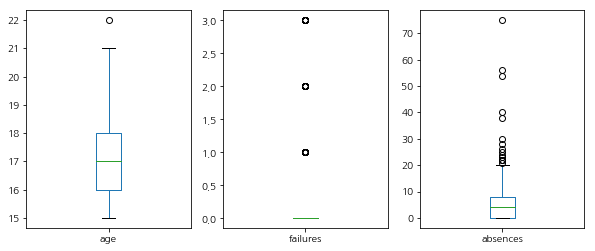

In [87]:
d1[num_cols].plot(kind='box', subplots=True, figsize=(10, 4))
plt.show()

IQR 기준으로 수치형 변수에서 범위 밖에 위치하여 이상치로 보이는 데이터가 일부 식별되었다. 
- 나이와 낙제여부는 실제 존재할 수 있는 값이므로 결측치 처리하지 않는다. 
- 결석여부는 상단에 이상치 의심 값들이 많이 존재하지만, 실제로도 70일 이상 결석이 가능하여 이상치로 단정지을 수 없고 대푯값으로 대치 시 원본데이터의 왜곡을 불러올 수 있으므로 삭제나 보간하지 않는다.

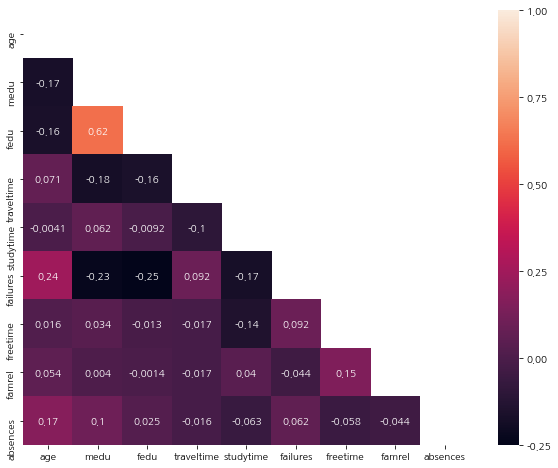

In [88]:
plt.figure(figsize=(10, 8))
corr = d1.corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

medu와 fedu 사이에 0.62로 비교적 강한 양의 선형상관관계가 관찰되었다.  
그 외에는 유의미한 상관관계가 없다. 

In [89]:
# 시험장에서는 pca 및 물어보지 않으면 미구현
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
cols = d1.select_dtypes('number').columns
vif['name'] = cols
vif['vif'] = [variance_inflation_factor(d1[cols].dropna().values, i) for i in range
(len(cols))]

display(vif)

,name,vif
0,age,43.584576
1,medu,12.238508
2,fedu,10.499730
3,traveltime,5.402466
4,studytime,7.131377
5,failures,1.407425
6,freetime,11.972091
7,famrel,20.086884
8,absences,1.592910


2.  **데이터를 전처리 하는 과정을 거치시오. 데이터 전처리를 통해 향후 예측분석에 미칠 영향을 논리적이고 타당한 근거를 들어 제시하시오(시각화 포함)(5점).**

In [90]:
d1.isna().mean()

sex           0.000000
age           0.000000
pstatus       0.000000
medu          0.010127
fedu          0.000000
guardian      0.000000
traveltime    0.000000
studytime     0.000000
failures      0.000000
freetime      0.000000
famrel        0.000000
absences      0.015190
dtype: float64

medu, absences 두 컬럼에서 매우 작은 비율의 결측치가 존재한다.  
1~1.5%로 전체 데이터 대비 매우 작은 비율을 차지하므로 보간하지 않고 삭제한다.  

In [91]:
print(f"결측치 삭제 전 데이터 수: {len(d1)}")
d1 = d1.dropna()
print(f"결측치 삭제 후 데이터 수: {len(d1)}")

결측치 삭제 전 데이터 수: 395
결측치 삭제 후 데이터 수: 385


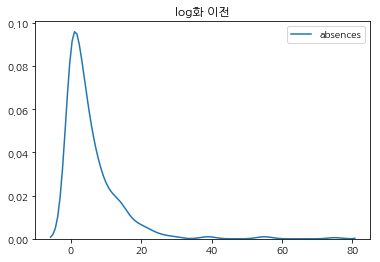

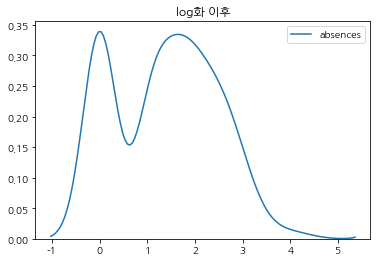

In [93]:
sns.kdeplot(d1['absences'])
plt.title('log화 이전')
plt.show()
d1['absences'] = np.log1p(d1['absences'])
sns.kdeplot(d1['absences'])
plt.title('log화 이후')
plt.show()

다음으로 데이터 분할 후 수치형 변수에 대한 범위 일치를 위한 스케일링, 
카테고리 변수에 대한 원핫인코딩을 수행한다. 
스케일링은 각 특성의 값의 범위와 분포를 일치시킴으로써 알고리즘 수렴속도 향상,  
거리기반 알고리즘 성능개선, 이상치 분포 왜곡 완화, 모델 해석의 일관성이라는 장점이 있다.

In [105]:
d1[cat_cols] = d1[cat_cols].astype('O')

In [121]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer

X = d1.drop(columns=['absences'])
Y = d1['absences']

#데이터 분할
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=42) 

n_cols = train_X.select_dtypes('number').columns
c_cols = train_X.select_dtypes('O').columns

# 전처리 프로세서
pre_processor = make_column_transformer(
    (StandardScaler(), n_cols), 
    (OneHotEncoder(handle_unknown='ignore'), c_cols), 
    remainder='passthrough'
)

# 트리기반
pre_processor2 = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), c_cols), 
    remainder='passthrough'
)

3.  **데이터 전처리를 진행하는데 시간이 부족하여 수행하지 못한 전처리 기법과 수행 방법을 제시하고, 향후 예측분석에 미칠 영향을 논리적이고 타당한 근거를 들어 제시하시오(5점).**


1. 일부 feature는 순위형 카테고리 변수로 label 인코더를 적용하는 것이 적절할 수 있다. feature 순위정보가 데이터 학습에 반영되므로 더욱 높은 성능을 낼 것으로 예상된다. 

2. 다중공선성 제어: log화 이후에도 일부 높은 다중공선성이 관찰되었음, PCA를 적용하면 다중공선성 제어가 가능하나, 모델학습 후 설명이 어렵다는 단점이 있어 적용하지 않음

4.  **전처리가 완료된 데이터를 활용하여 예측 분석에 적합한 알고리즘을 3개 이상 추천하고, 이들 중 2개를 선정하여 이를 선정한 이유를 타당한 근거를 들어 제시하시오(5점).**

- 1: 랜덤포레스트 회귀모델(선정)
    - 과적합 억제: 여러 개의 결정 트리를 평균하여 과적합 리스크를 낮춘다.
    - 이상치 강건성: 트리 기반 특성상 극단치에 민감하지 않아 전처리 후에도 안정적 예측 가능
    - 변수 중요도 제공: 학습 완료 후 각 피처의 상대적 중요도를 계산하여 모델 해석 및 Feature Selection에 활용
 * 단점: 대규모 학습 시 높은 비용과 속도 저하 발생
    
- 2: SVR(선정)
    - 강건한 일반화 성능: 마진(maximum margin) 개념을 기반으로 학습하여 과적합을 방지하고, 새로운 데이터에 대해 안정적인 예측
    - 비선형 관계 모델링: 다양한 커널(예: RBF, 다항식, 시그모이드)을 활용해 입력 공간을 고차원 특징 공간으로 매핑함으로써 복잡한 비선형 패턴을 효과적으로 학습
    - 고차원 데이터에 적합: 특성 차원이 샘플 수보다 많거나 희소성이 높은 데이터에서도 성능 저하가 덜하며, 커널 트릭을 통해 직접 차원 축소 없이 처리
    - 견고성: 손실 함수에 ε-불감 손실(ε-insensitive loss)을 사용하여 소량의 잡음과 이상치에 둔감하게 반응
 * 단점: 높은 계산비용으로 대규모 데이터에 적합하지 않음, 파라미터 조정 필요 


- 2: LightGBM 회귀모델(비선정)

    - 고속 학습 및 예측: Histogram 기반 학습으로 메모리 사용량과 학습 시간을 획기적으로 절감
    - 확장성: 대규모 데이터와 높은 차원에도 효율적이며, GPU 학습 지원으로 추가 가속 가능
    - 정교한 부스팅 기능: Leaf-wise 트리 분할 전략으로 작은 학습 오차부터 우선 개선하여 높은 정확도 달성
 * 단점: 작은 데이터셋에서 과적합 우려, 파라미터 튜닝 필요
 
해당 데이터셋은 400개 미만의 소-중규모 데이터이므로 랜덤포레스트와 svr을 선정

5.  **예측분석을 적용하여 평가할 때의 평가 지표를 선정하고 평가 지표를 선정한 이유를 논리적이고 타당한 근거를 들어 제시하시오(5점).**

평균제곱근오차 (RMSE)를 선정한다.  
제곱오차의 평균(mse)의 제곱근으로 큰 오차에 가중치를 부여하여 중대한 예측실수를 강조하여, 모델이 극단치 예측에 신경쓰도록 유도하며, 예측성능을 쉽게 알아볼 수 있다. 

평균절대오차(mae)와 결정계수(r2)도 보조적으로 활용한다.

- MAE: 실제값과 예측값 간 절대오차의 평균, 단위가 원래값과 동일하여 오차크기 직관적 이해에 유리
- r2: 1-(잔차제곱합/전체편차제곱합)으로 모델이 종속변수 전체변동량 중 몇퍼센트를 설명하는지 비율로 제시


-  **MAE**: 해석 용이성과 이상치 강건성  
-  **RMSE**: 대형 오차 집중 관리  
-  **R²**: 전반적 설명력 평가  

이 세 가지 지표를 조합해 평가하면, **모델의 오차 크기, 오차 분포 특성, 설명력**을 종합적으로 검토할 수 있어 예측 분석 결과를 보다 정밀하고 신뢰성 있게 해석할 수 있다.

6.  **선정한 2개의 알고리즘을 바탕으로 분석을 진행하고, 이를 선정한 평가지표와 함께 나타내시오(시각화 포함)(5점).**

In [124]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

#모델정의
rf = Pipeline([
    ('preprocess', pre_processor2), 
    ('regressor', RandomForestRegressor(random_state=42))
])

svr = Pipeline([
    ('preprocess', pre_processor), 
    ('regressor', SVR())
])

model_list = [('랜덤포레스트 회귀', rf), ('svr', svr)]
dt_list = [('tran', train_X, train_Y), ('test', test_X, test_Y)]

rs = pd.DataFrame(columns=['name', 'data', 'rmse', 'mae', 'r2', 'time'])

#모델학습
for m_name, model in model_list:
    start = time.time()
    model.fit(train_X, train_Y)
    end = time.time()
    t = end - start
    for d_name, x, y in dt_list:
        pred = model.predict(x)
        rmse = np.sqrt(mean_squared_error(y, pred))
        mae = mean_absolute_error(y, pred)
        r2 = r2_score(y, pred)
        rs.loc[len(rs)] = [m_name, d_name, rmse, mae, r2, t]
display(rs)

,name,data,rmse,mae,r2,time
0,랜덤포레스트 회귀,tran,0.412074,0.346203,0.848348,0.296185
1,랜덤포레스트 회귀,test,1.242374,1.039585,-0.375347,0.296185
2,svr,tran,0.768501,0.575637,0.472544,0.016250
3,svr,test,1.195697,1.001279,-0.273942,0.016250


In [16]:
print('decision tree best score : ', -decisiontree_search.best_score_)

decision tree best score :  5.753400282022642


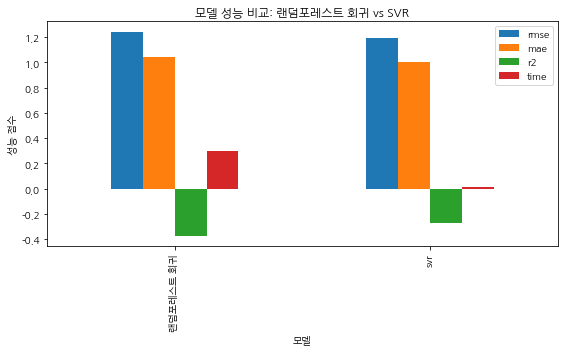

In [128]:
tmp = rs[rs['data'] == 'test'].drop(columns=['data'])
tmp = tmp.set_index('name')
ax = tmp.plot(kind='bar', figsize=(8, 5))

# 축 레이블 및 제목 설정
ax.set_xlabel('모델')
ax.set_ylabel('성능 점수')
ax.set_title('모델 성능 비교: 랜덤포레스트 회귀 vs SVR')
plt.tight_layout()
plt.show()

두 모델의 학습결과이다. 두 모델 모두 과적합이 관찰되지만 랜덤포레스트의 과적합 정도가  
더 심하며, test set 기준으로 전반적으로 SVR의 성능이 더 뛰어나며 학습시간 또한 짧음을 알 수 있다. SVR을 채택한다. 

7.  **위에서 구축한 모델의 일반화 가능성에 대해서 논리적으로 타당한 근거를 바탕으로 제시하시오(5점).**

채택한 SVR 모델의 기준으로 K-FOLD 교차검증을 수행해 해당 모델이 일반화 성능을 보여주고 있는지 여부를 확인할 수 있다.   
5-FOLD를 적용하고, 5개 FOLD 모두에서 비슷한 성능을 보인다면 일반화 모델이라고 볼 수 있다. 

In [142]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer


mae = make_scorer(mean_absolute_error, greater_is_better=False)
mse = make_scorer(mean_squared_error, greater_is_better=False)
r2 = make_scorer(r2_score, greater_is_better=False)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_s = -cross_val_score(svr, train_X, train_Y, cv=kf, scoring=mae)
rmse_s = np.sqrt(-cross_val_score(svr, train_X, train_Y, scoring=mse))
r2_s = -cross_val_score(svr, train_X, train_Y, scoring=r2)

rs = pd.DataFrame()
rs['fold'] = np.arange(1, 6)
rs['mae'] = mae_s
rs['rmse'] = rmse_s
rs['r2'] = r2_s
rs = rs.set_index('fold', drop=True)
display(rs)

,mae,rmse,r2
fold,,,
1,0.947106,1.155385,-0.102876
2,0.886951,1.126012,-0.098712
3,0.926903,1.136625,-0.107581
4,0.939603,1.037679,0.037637
5,0.921772,1.028284,-0.220188


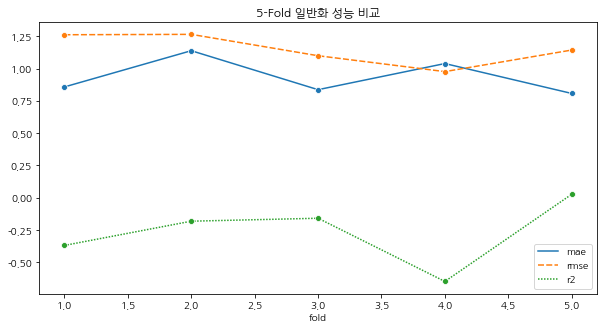

In [141]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=rs, marker='o')
plt.title('5-Fold 일반화 성능 비교')
plt.show()

5-fold 학습결과, 모든 성능지표에서 대체로 일반적인 성능이 측정된 것을 확인할 수 있다.  
따라서 해당 모델은 일반화가 가능한다. 

8.  **앞서 구축한 모델을 더욱 발전시키기 위한 방법을 서술하고 그 방법이 모델에 어떤 영향을 미칠 수 있는지를 타당한 근거를 들어 제시하시오(5점).**

SVC 모델의 경우 하이퍼파라미터 최적화를 해야 높은 성능이 보장되는 모델이다.  
시간이 있다면 실험을 거쳐 하이퍼 파라미터 최적 후보를 도출하고, grid-search를 통해 최적의 파라미터를 도출해낸다면 더 좋은 성능의 모델이 도출될 것이다. 

또한 모델학습에 중요한 영향을 미치는 변수를 permutation importance, 변수 제거법 등을 적용하여 차원수를 줄여 최적화 할 수 있을 것이다. 

## 문제 2

야생 동물 생물학자들은 국립 공원에서 어부들이 얼마나 많은 물고기를 잡는지 모델링하고자 합니다.

**Data description**

-   camper : 캠핑카를 가져왔는지 여부

-   persons : 그룹에 속한 사람의 수

-   child : 그룹에 속한 어린이 수

-   count : 그룹에서 잡은 물고기의 수

In [145]:
dat = pd.read_csv('problem2.csv')

In [146]:
print(dat.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   nofish    250 non-null    int64  
 1   livebait  250 non-null    int64  
 2   camper    250 non-null    int64  
 3   persons   250 non-null    int64  
 4   child     250 non-null    int64  
 5   xb        250 non-null    float64
 6   zg        250 non-null    float64
 7   count     250 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 15.8 KB
None


In [147]:
dat = dat.drop(columns=['nofish'])
dat['livebait'] = dat['livebait'].astype('category')
dat['camper'] = dat['camper'].astype('category')

In [148]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   livebait  250 non-null    category
 1   camper    250 non-null    category
 2   persons   250 non-null    int64   
 3   child     250 non-null    int64   
 4   xb        250 non-null    float64 
 5   zg        250 non-null    float64 
 6   count     250 non-null    int64   
dtypes: category(2), float64(2), int64(3)
memory usage: 10.6 KB


1.  **데이터에 과대산포가 존재하는지 판단하시오(5점).**

분산/평균 비로 과대산포 여부를 확인할 수 있다.  
이 비가 1을 넘어가면 과대산포로 간주한다.  
약 41배 정도 되므로 과대산포이다.

In [159]:
v_ratio = dat['count'].var(ddof=0)/dat['count'].mean()
print(f"분산/평균 비: {v_ratio}")

분산/평균 비: 40.90788349514564


2.  **과대산포를 반영한 회귀 모델을 적합하시오(5점).**

단위 공간 내 사건의 횟수를 추정하는 회귀모델을 구현해야 한다.  
포아송분포는 같은 시/공간 내 발생확률이 일정함(균등분포)을 가정하므로 과대산포일 시   
사용할 수 없다.  
따라서 포아송분포 대신 사용할 수 있는 음이항 분포를 사용한다.

In [163]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm('count ~ C(livebait)+C(camper)+persons+child+xb+zg', 
                   data=dat, family=sm.families.NegativeBinomial()).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  count   No. Observations:                  250
Model:                            GLM   Df Residuals:                      243
Model Family:        NegativeBinomial   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -300.07
Date:                Sun, 14 Sep 2025   Deviance:                       81.803
Time:                        15:06:44   Pearson chi2:                     63.7
No. Iterations:                    13   Pseudo R-squ. (CS):             0.8958
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.2660      0.492  

모델의 설명력 0.8958 정도로 높음, C(camper)[T.1], child, persons의 계수가 통계적으로 유의하지 않음

3.  **Zero-inflation 모델을 적합하고, 모델 적합도를 통계적으로 검정하시오(5점).**


-   귀무가설: 모든 계수들이 0이다.

-   대립가설: 0이 아닌 계수가 존재한다.

In [167]:
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from scipy.stats import chi2

model2 = ZeroInflatedNegativeBinomialP.from_formula(
    'count ~ C(livebait)+C(camper)+persons+child+xb+zg', 
    data=dat, dist='negbin').fit()

llf = model2.llf #full model
null_model = ZeroInflatedNegativeBinomialP.from_formula(
    'count ~ 1', data=dat, dist='negbin').fit() #상수항만 가진 모델
llnull = null_model.llf

stat = round(-2*(llnull - llf), 3)
dof = model2.df_model - null_model.df_model

p = chi2.sf(stat, dof)

print(f"검정통계량: {stat}")
print(f"p-value: {p:.3f}")

         Current function value: 1.083893
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37
         Current function value: 1.857757
         Iterations: 35
         Function evaluations: 36
         Gradient evaluations: 36
검정통계량: 386.932
p-value: 0.000


유의수준 5% 하에서 p-value가 0으로 작으므로 귀무가설 기각  
따라서 모델에 0이 아닌 계수가 존재하며, 모델이 데이터에 적합함

4.  **2번과 3번 모델을 비교한 후 어떤 모델이 해당 데이터에 더 적합한지 판단하시오(5점).**

AIC와 BIC는 회귀모델 성능비교를 위해 주로 사용되는 성능지표이다.  
이 중 AIC를 통해 비교한다. 수치가 작을수록 더 성능이 좋은 모델이다. 

In [171]:
print(f"음이항분포 모델 aic: {model.aic}")
print(f"Zero-inflation 모델 aic: {model2.aic}")

음이항분포 모델 aic: 614.1389276957025
Zero-inflation 모델 aic: 555.9464687044747


Zero-inflation 모델 aic: 555.9464687044747로 더 낮으므로  
해당 모델을 채택한다. 

## 문제 3

In [172]:
dat = pd.read_csv('problem3.csv', encoding='cp949')

1.  **회귀식이 통계적으로 유의한지 판단하시오(5점).**


-   귀무가설 : 모든 회귀계수는 0이다.
-   대립가설 : 적어도 하나의 회귀계수는 0이 아니다.

In [173]:
dat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   광고횟수    11 non-null     int64 
 1   광고비     11 non-null     object
 2   매출액     11 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 392.0+ bytes


In [174]:
model = smf.ols(formula='매출액 ~ C(광고비) + 매출액', data=dat).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    매출액   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.910e+30
Date:                Sun, 14 Sep 2025   Prob (F-statistic):          3.57e-120
Time:                        15:24:59   Log-Likelihood:                 344.13
No. Observations:                  11   AIC:                            -682.3
Df Residuals:                       8   BIC:                            -681.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.599e-14   9.59e-15      1.667   

유의수준 5% 하에서 모델의 f 통계량 p-value가 3.57e-120로 통계적으로 유의(적어도 하나의 회귀계수는 0이 아니다.)  
설명력이 1로 데이터의 분포를 잘 설명하는 모델    
feature별 p-value 확인 시 C(광고비)[T.높음]회귀계수는 통계적으로 유의하지 않으며, 매출액의 회귀계수는 통계적으로 유의하다.  

2.  **광고비 변수를 가변수 처리후 다중회귀를 수행하여 회귀계수가 통계적으로 유의한지 검정하시오(5점).**


-   귀무가설 : 해당 회귀계수는 0이다.

-   대립가설 : 해당 회귀계수는 0이 아니다.

In [183]:
x = dat.drop(columns='매출액')
y = dat['매출액']
x = pd.get_dummies(x, columns=['광고비'], drop_first=True)
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    매출액   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     221.2
Date:                Sun, 14 Sep 2025   Prob (F-statistic):           9.96e-08
Time:                        15:38:37   Log-Likelihood:                -11.883
No. Observations:                  11   AIC:                             29.77
Df Residuals:                       8   BIC:                             30.96
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.1641      0.556     21.876      0.0

모델의 p-value는 통계적으로 유의하며, 광고비를 더미화 후 다중회귀 적용 시 마찬가지로  
유의수준 5% 하에서p-value 0.358로 광고비의 회귀계수가 통계적으로 유의하지 않음을 알 수 있다. 

## 문제 4

A 생산라인의 제품 평균은 5.7mm이고 표준편차는 0.03입니다. B 생산라인의 제품 평균은 5.6mm이고 표준편차는 0.04입니다. 두 생산라인의 제품 평균이 서로 다른지 검정하려고 합니다. 주어진 정보를 바탕으로 5% 유의수준에서 Z-검정을 수행하세요. (Z(0.05) = 1.65)


1.  **두 생산라인의 평균이 동일한지 여부를 검정하기 위한 귀무가설과 대립가설을 세우시오(5점).**

    -   귀무가설(H₀): A 생산라인과 B 생산라인의 평균은 동일하다.

    -   대립가설(H₁): 두 생산라인의 평균은 차이가 있다.(A가 더 큼)

2.  **두 생산라인의 평균 제품 크기가 통계적으로 유의미하게 차이가 있는지 검정하시오(5점).**

In [187]:
from scipy.stats import norm

x1, x2 = 5.7, 5.6
sd1, sd2 = 0.03, 0.04

n1, n2 = 30, 30 #여기서 제시되진 않았지만 z 검정 수행하려면 30이상이어야 함
a = 0.05 #유의수준

d = x1 - x2 #두 평균의 차이
d0 = 0 # 두평균의 차이 추정
se = np.sqrt(sd1**2/n1 + sd2**2/n2) #오차
stat = (x1-x2-d0)/se #검정통계량

# p = (1-norm.cdf(np.abs(stat)))*2 #between
p = 1-norm.cdf(stat) #이건 right

print(f"z 검정통계량: {stat}")
print(f"p-value: {p:.3f}")

z 검정통계량: 10.954451150103381
p-value: 0.000


유의수준 5% 하에서 z검정 우측검정의 p-value가 0으로 작으므로 귀무가설을 기각한다.  
따라서 A라인의 평균이 더 크다는 것은 통계적으로 유의하다.

## 문제 5

다음은 특정 바이러스에 대한 검사 결과를 나타내는 분류표입니다. 이 표를 사용하여 베이지안 방법을 적용하여 양성으로 예측된 사람이 실제로 양성일 확률을 계산하세요(10점).

|     -       | 양성(실제) | 음성(실제) |
|------------|------------|------------|
| 양성(예측) | 370        | 10         |
| 음성(예측) | 15         | 690        |

In [189]:
#P(양성|양성예측) = P(양성예측|양성)*P(양성)|P(양성예측)

tp = 370
fp = 10
tn = 690
fn = 15

sm = tp+fp+tn+fn

precision = (tp+fp)/sm #양성예측확률
positive = (tp+fn)/sm #양성확률
p_actual = tp/(tp+fn)  #양성예측|양성

ans = (p_actual*positive)/precision

print(f"P(양성|양성예측): {ans}")

P(양성|양성예측): 0.9736842105263159


## 문제 6

다음은 정규분포에서 추출한 데이터입니다. 해당 데이터를 사용하여 신뢰구간을 계산하세요.

In [190]:
dat = pd.read_csv('problem6.csv')

In [191]:
dat

,x
0,2.937355
1,3.018364
2,2.916437
3,3.159528
4,3.032951
5,2.917953
6,3.048743
7,3.073832
8,3.057578
9,2.969461


1.  **모분산을 모르는 경우, 주어진 데이터를 사용하여 95% 신뢰구간을 T 분포를 이용해 계산하시오(5점).**

In [202]:
from scipy.stats import t

# 평균, 갯수, 표본표준편차
x, n, s = dat.mean().values[0], len(dat), dat.std(ddof=1).values[0]
a = 0.05 #유의수준
dof = n - 1 # 자유도

se = s/np.sqrt(n)
conf_t = t.ppf(1-a/2, dof)
me = conf_t*se #허용오차


print(f"평균: {x}")
print(f"95% 신뢰구간: {x-me} ~ {x+me}")

평균: 3.013220278129598
95% 신뢰구간: 2.9573805225901917 ~ 3.0690600336690044


2.  **모표준편차가 0.1인 것을 알고 있을 때, Z 분포를 이용하여 주어진 데이터의 95% 신뢰구간을 구하시오(5점).**

In [203]:
# 평균, 갯수, 표본표준편차
x, n, s = dat.mean().values[0], len(dat), 0.1
a = 0.05 #유의수준
dof = n - 1 # 자유도

se = s/np.sqrt(n)
down, up = norm.interval(1-a, loc=x, scale=se)
me = up - down

print(f"평균: {x}")
print(f"95% 신뢰구간: {down} ~ {up}")

평균: 3.013220278129598
95% 신뢰구간: 2.951240774899142 ~ 3.075199781360054
